In [8]:
# import libraries
from dd.autoref import BDD
from itertools import product
import math
import operator

from __future__ import annotations
from dataclasses import dataclass
from typing import Any

import graphviz

import numpy as np
from scipy.stats import norm

In [4]:
#!pip install graphviz

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [9]:
# create states and actions
N_STATES   = 4
STATE_VALS = [0, 50, 100, 150]
VARS       = ["X", "Y", "Z"]
VARS_P     = ["X_p", "Y_p", "Z_p"]
ACTION_COST = {"a1": 10, "a2": 10, "a3": 0}

In [10]:
# build ADD class

# ── nodes ──────────────────────────────────────────────────────────────────────

@dataclass(frozen=True)
class Leaf:
    value: float

    def __repr__(self):
        return f"Leaf({self.value})"

@dataclass(frozen=True)
class Node:
    var:      str
    children: tuple  # one per state value, ordered by STATE_VALS

    def __repr__(self):
        return f"Node({self.var})"

# ── manager (handles hash-consing) ────────────────────────────────────────────

class ADD:
    def __init__(self, state_vals: list):
        self.state_vals  = state_vals
        self._leaf_cache = {}   # value -> Leaf
        self._node_cache = {}   # (var, children_tuple) -> Node

    def leaf(self, value: float) -> Leaf:
        if value not in self._leaf_cache:
            self._leaf_cache[value] = Leaf(value)
        return self._leaf_cache[value]

    def node(self, var: str, children: tuple) -> Leaf | Node:
        # Reduction rule: all children identical -> return child
        if len(set(id(c) for c in children)) == 1:
            return children[0]
        key = (var, children)
        if key not in self._node_cache:
            self._node_cache[key] = Node(var, children)
        return self._node_cache[key]

    def build(self, fn, var_order: list) -> Leaf | Node:
        """Build an ADD from a function f(assignment) -> float."""
        def _build(depth, assignment):
            if depth == len(var_order):
                return self.leaf(fn(assignment))
            var = var_order[depth]
            children = tuple(
                _build(depth + 1, {**assignment, var: v})
                for v in self.state_vals
            )
            return self.node(var, children)
        return _build(0, {})

    def evaluate(self, root: Leaf | Node, assignment: dict) -> float:
        """Evaluate ADD at a given assignment."""
        node = root
        while isinstance(node, Node):
            val = assignment[node.var]
            idx = self.state_vals.index(val)
            node = node.children[idx]
        return node.value

    def apply(self, op, a: Leaf | Node, b: Leaf | Node) -> Leaf | Node:
        """Apply a binary operation to two ADDs."""
        cache = {}
        def _apply(x, y):
            key = (id(x), id(y))
            if key in cache:
                return cache[key]
            if isinstance(x, Leaf) and isinstance(y, Leaf):
                result = self.leaf(op(x.value, y.value))
            elif isinstance(x, Node) and isinstance(y, Node) and x.var == y.var:
                result = self.node(x.var, tuple(
                    _apply(cx, cy)
                    for cx, cy in zip(x.children, y.children)
                ))
            elif isinstance(x, Node):
                result = self.node(x.var, tuple(
                    _apply(cx, y) for cx in x.children
                ))
            else:
                result = self.node(y.var, tuple(
                    _apply(x, cy) for cy in y.children
                ))
            cache[key] = result
            return result
        return _apply(a, b)

    def count_nodes(self, root: Leaf | Node) -> int:
        seen = set()
        def _walk(n):
            if id(n) in seen:
                return 0
            seen.add(id(n))
            if isinstance(n, Leaf):
                return 1
            return 1 + sum(_walk(c) for c in n.children)
        return _walk(root)

    def count_leaves(self, root: Leaf | Node) -> int:
        seen = set()
        def _walk(n):
            if id(n) in seen:
                return 0
            seen.add(id(n))
            if isinstance(n, Leaf):
                return 1
            return sum(_walk(c) for c in n.children)
        return _walk(root)

    def to_dot(self, root: Leaf | Node, title: str = "ADD") -> str:
        """Visualize ADD"""
        lines = [
            f'digraph "{title}" {{',
            '  node [fontname="Helvetica"];',
            '  edge [fontname="Helvetica"];',
            ]
        seen = set()

        def node_id(n):
            return f"n{id(n)}"

        def _walk(n):
            if id(n) in seen:
                return
            seen.add(id(n))
            nid = node_id(n)
            if isinstance(n, Leaf):
                lines.append(
                    f'  {nid} [shape=square, style=filled, '
                    f'fillcolor=lightblue, label="{n.value}"];'
                )
            else:
                lines.append(f'  {nid} [shape=ellipse, label="{n.var}"];')
                for val, child in zip(self.state_vals, n.children):
                    lines.append(
                        f'  {nid} -> {node_id(child)} [label="{val}"];'
                    )
                    _walk(child)

        _walk(root)
        lines.append("}")
        return "\n".join(lines)

### Create reward ADD

In [11]:
# reward function
def reward_fn(s, a):
    return s["X"] + s["Y"] + s["Z"] + ACTION_COST[a]

In [12]:
# Build
mgr = ADD(STATE_VALS)

reward_adds = {
    a: mgr.build(lambda s, a=a: reward_fn(s, a), VARS)
    for a in ACTION_COST
}

In [13]:
# evaluate
print(mgr.evaluate(reward_adds["a1"], {"X": 50, "Y": 100, "Z": 150}))

310


In [14]:
# Node counts
for a, add in reward_adds.items():
    print(f"{a}: {mgr.count_nodes(add)} nodes, {mgr.count_leaves(add)} leaves")

a1: 22 nodes, 10 leaves
a2: 22 nodes, 10 leaves
a3: 22 nodes, 10 leaves


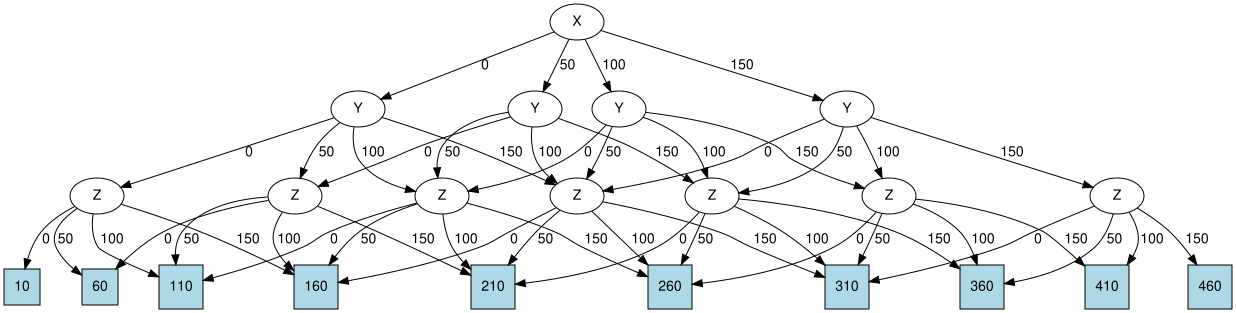

In [14]:
dot_str = mgr.to_dot(reward_adds["a1"], title="Reward ADD (a1)")
graphviz.Source(dot_str).render("reward_a1", format="png", cleanup=True)

# Or view inline in a notebook:
graphviz.Source(dot_str)

### Create transition ADD

In [15]:
# ── problem setup ──────────────────────────────────────────────────────────────

params = {
    "p_detect": 0.8,
    "st_mean":  0.0,
    "st_sd":    1.0,
    "rho":      0.5,
}

# action_set: each column is an action, rows are (a_X, a_Y, a_Z)
# col 0 -> action applied to X only
# col 1 -> action applied to Y only
# col 2 -> action applied to Z only
action_set = np.array([[1, 0, 0],
                       [0, 1, 0],
                       [0, 0, 1]])

p_increase = 1.5
dd         = 4.0   # carrying capacity (log scale)

In [16]:
# ── build transition matrix for one subsystem ─────────────────────────────────

def get_transition_subsystem(params, dd, states, p_increase, a_binary):
    """
    Returns T[s', s] = P(s' | s, a) for a single subsystem.
    a_binary: 1 if action applied to this subsystem, 0 otherwise.
    """
    states   = np.array(states, dtype=float)
    seq_st   = np.log(states + 1e-9)   # avoid log(0)
    n        = len(states)

    pcap = params["p_detect"] * p_increase if a_binary else 0.0

    # weights over continuous state draw
    s_t = norm.pdf(seq_st, params["st_mean"], params["st_sd"])
    s_t = s_t / s_t.sum()

    out = np.zeros((n, n))

    for j, s in enumerate(states):
        survived    = s * (1 - pcap)
        lambda_next = (
            np.exp(seq_st) +
            params["rho"] * survived * (1 - survived / np.exp(dd))
        )

        prob = np.zeros(n)
        for i, lam in enumerate(lambda_next):
            idx       = np.argmin(np.abs(lam - states))
            prob[idx] += s_t[i]

        out[:, j] = prob / prob.sum()

    return out   # shape: (n_next, n_current)

In [17]:
# ── build transition ADDs ──────────────────────────────────────────────────────

def build_transition_add(mgr, params, dd, states, p_increase, a_binary,
                         var_current, var_next):
    """
    Build ADD representing P(var_next | var_current, a).
    Variables: var_current (current state), var_next (next state).
    """
    T = get_transition_subsystem(params, dd, states, p_increase, a_binary)

    # T[i, j] = P(s'=states[i] | s=states[j])
    # ADD maps (var_current, var_next) -> probability
    def prob_fn(assignment):
        s      = assignment[var_current]
        s_next = assignment[var_next]
        j      = states.index(s)
        i      = states.index(s_next)
        return T[i, j]

    return mgr.build(prob_fn, [var_current, var_next])

In [18]:
# ── build all transition ADDs ──────────────────────────────────────────────────

mgr = ADD(STATE_VALS)

# For each action (column of action_set), build per-subsystem transition ADDs
n_actions = action_set.shape[1]

transition_adds = {}   # (action_idx, var) -> ADD

for a_idx in range(n_actions):
    transition_adds[a_idx] = {}
    for v_idx, (var, var_p) in enumerate(zip(VARS, VARS_P)):
        a_binary = int(action_set[v_idx, a_idx])
        add = build_transition_add(
            mgr, params, dd, STATE_VALS, p_increase, a_binary,
            var_current=var, var_next=var_p
        )
        transition_adds[a_idx][var] = add
        print(f"Action {a_idx}, {var}: "
              f"{mgr.count_nodes(add)} nodes, "
              f"{mgr.count_leaves(add)} leaves")

Action 0, X: 5 nodes, 4 leaves
Action 0, Y: 10 nodes, 6 leaves
Action 0, Z: 10 nodes, 6 leaves
Action 1, X: 10 nodes, 6 leaves
Action 1, Y: 5 nodes, 4 leaves
Action 1, Z: 10 nodes, 6 leaves
Action 2, X: 10 nodes, 6 leaves
Action 2, Y: 10 nodes, 6 leaves
Action 2, Z: 5 nodes, 4 leaves


In [19]:
# create joint transition matrix
def joint_transition_add(mgr, transition_adds, a_idx):
    """
    Joint transition ADD: P(X',Y',Z' | X,Y,Z, a)
    = P(X'|X,a) * P(Y'|Y,a) * P(Z'|Z,a)  [conditional independence]
    """
    adds   = list(transition_adds[a_idx].values())
    result = adds[0]
    for add in adds[1:]:
        result = mgr.apply(operator.mul, result, add)
    return result

joint_adds = {a: joint_transition_add(mgr, transition_adds, a)
              for a in range(n_actions)}

0.0024306316278967666


In [ ]:
# Evaluate: P(X'=100, Y'=50, Z'=0 | X=50, Y=100, Z=150, a=0)
assignment = {"X": 50, "Y": 100, "Z": 150,
              "X_p": 100, "Y_p": 50, "Z_p": 0}
print(mgr.evaluate(joint_adds[0], assignment))

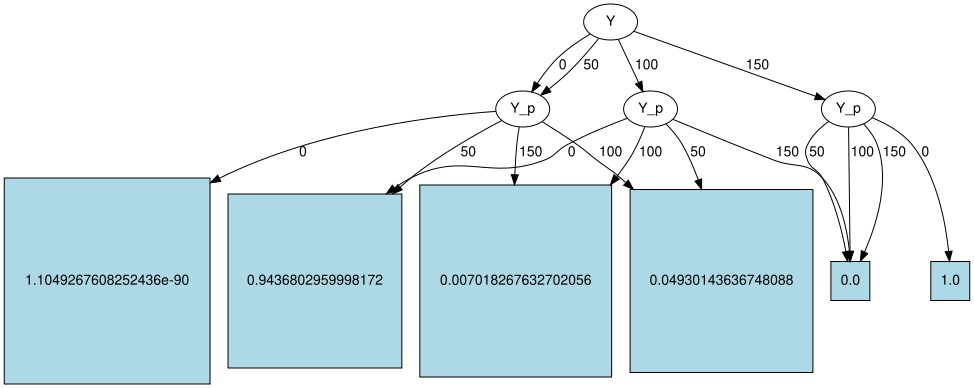

In [20]:
# Visualise
dot = mgr.to_dot(transition_adds[0]["Y"], title="P(Y'|Y, a=0)")
graphviz.Source(dot)

## SPUDD algorithm

In [5]:
import operator
from functools import reduce

In [25]:
# ── helper: restrict ADD to a specific variable assignment ────────────────────
def restrict(mgr, root, var, val):
    """Fix variable `var` to `val` in ADD, returning reduced ADD."""
    cache = {}
    def _restrict(n):
        if id(n) in cache:
            return cache[id(n)]
        if isinstance(n, Leaf):
            return n
        if n.var == var:
            idx = mgr.state_vals.index(val)
            result = _restrict(n.children[idx])
        else:
            result = mgr.node(n.var, tuple(_restrict(c) for c in n.children))
        cache[id(n)] = result
        return result
    return _restrict(root)

# ── helper: sum out a primed variable ─────────────────────────────────────────
def sum_out(mgr, root, var):
    """Sum ADD over all values of `var`, marginalising it out."""
    result = mgr.leaf(0.0)
    for val in mgr.state_vals:
        branch = restrict(mgr, root, var, val)
        result = mgr.apply(operator.add, result, branch)
    return result

# ── helper: max over actions ───────────────────────────────────────────────────
def add_max(mgr, a, b):
    return mgr.apply(lambda x, y: max(x, y), a, b)

# ── helper: scalar multiply ───────────────────────────────────────────────────
def scalar_mul(mgr, root, scalar):
    """Multiply every leaf of ADD by a scalar."""
    cache = {}
    def _mul(n):
        if id(n) in cache:
            return cache[id(n)]
        if isinstance(n, Leaf):
            result = mgr.leaf(n.value * scalar)
        else:
            result = mgr.node(n.var, tuple(_mul(c) for c in n.children))
        cache[id(n)] = result
        return result
    return _mul(root)

# ── helper: max difference between two ADDs (for convergence check) ───────────
def max_diff(mgr, a, b):
    diff = mgr.apply(lambda x, y: abs(x - y), a, b)
    vals = []
    def _collect(n):
        if isinstance(n, Leaf):
            vals.append(n.value)
        else:
            for c in n.children:
                _collect(c)
    _collect(diff)
    return max(vals)

In [26]:
# ── regress value function through one action ─────────────────────────────────
def regress(mgr, V, transition_adds_a, discount):
    """
    Compute expected discounted future value for action a.
    Compute Q(s, a) = discount * sum_{s'} P(s'|s,a) * V(s')
    
    For independent subsystems, joint transition factors:
    P(s'|s,a) = P(X'|X,a) * P(Y'|Y,a) * P(Z'|Z,a)
    
    We compute sum_{X',Y',Z'} P(X'|X,a)*P(Y'|Y,a)*P(Z'|Z,a)*V(X',Y',Z')
    by summing out primed variables one at a time.
    """
    # Start with V(X', Y', Z') and work through each subsystem
    result = V

    # loop through one subsystem at a time
    for var, var_p in zip(VARS, VARS_P):

        # get transition ADD for this subsystem
        T_var = transition_adds_a[var]  # P(var_p | var, a)
        
        # Rename V's var to var_p by building a new ADD
        # Then multiply P(var_p | var) * V(..., var_p, ...)
        # and sum out var_p
        
        # Multiply transition by current result
        # P(X_p | X, a) * V(X', Y', Z')
        product = mgr.apply(operator.mul, T_var, result)
        
        # Sum out the primed variable
        result = sum_out(mgr, product, var_p)
    
    return scalar_mul(mgr, result, discount)

In [27]:
# ── rename primed variables in V to match primed vars ─────────────────────────
def rename_to_primed(mgr, V):
    """Return copy of V with VARS replaced by VARS_P."""
    cache = {}
    def _rename(n):
        if id(n) in cache:
            return cache[id(n)]
        if isinstance(n, Leaf):
            return n
        new_var = VARS_P[VARS.index(n.var)] if n.var in VARS else n.var
        result = mgr.node(new_var, tuple(_rename(c) for c in n.children))
        cache[id(n)] = result
        return result
    return _rename(V)

In [32]:
# ── SPUDD value iteration ──────────────────────────────────────────────────────
def spudd(mgr, reward_adds, transition_adds, discount, tolerance, max_iter=1000):
    """
    SPUDD value iteration.
    
    Args:
        mgr:              ADD manager
        reward_adds:      dict {action_name -> reward ADD over VARS}
        transition_adds:  dict {action_idx -> {var -> transition ADD}}
        discount:         float, discount factor
        tolerance:        float, convergence threshold
        max_iter:         int, maximum iterations
    
    Returns:
        V:       value function ADD over VARS
        policy:  policy ADD over VARS (action index at each state)
    """
    # Map action names to indices
    action_names = list(reward_adds.keys())  # ['a1', 'a2', 'a3']
    
    # Initialise V = 0
    V = mgr.leaf(0.0)
    
    for iteration in range(max_iter):
        V_primed = rename_to_primed(mgr, V)

        # empty list to store one Q-value ADD per action
        Q_adds = []
        
        for a_idx, a_name in enumerate(action_names):
            
            # Regress V through transition
            # Compute the expected discounted future value
            # discount * sum_{s'} P(s'|s,a) * V(s')
            future = regress(mgr, V_primed, transition_adds[a_idx], discount)
            
            # Add immediate reward to future value: Q(s,a) = R(s,a) + discount * E[V(s')]
            Q_a = mgr.apply(operator.add, reward_adds[a_name], future)

            # Store the Q-value ADD for this action
            # Q_adds contains one ADD per action, where each ADD maps every state s to the value of taking that action from s
            Q_adds.append(Q_a)
        
        # V_new = max_a Q(s, a)
        # takes the element-wise maximum across all the Q-value ADDs for every state s
        V_new = reduce(lambda a, b: add_max(mgr, a, b), Q_adds)
        
        # Check convergence
        delta = max_diff(mgr, V, V_new)
        print(f"Iteration {iteration+1}: delta = {delta:.6f}, "
              f"nodes = {mgr.count_nodes(V_new)}")
        
        V = V_new
        if delta < tolerance:
            print(f"Converged after {iteration+1} iterations.")
            break
    
    # Extract policy: for each state, which action gives max Q?
    policy_adds = []
    V_primed = rename_to_primed(mgr, V)
    for a_idx, a_name in enumerate(action_names):
        future = regress(mgr, V_primed, transition_adds[a_idx], discount)
        Q_a = mgr.apply(operator.add, reward_adds[a_name], future)
        policy_adds.append(Q_a)
    
    return V, policy_adds

In [21]:
V = mgr.leaf(0.0)

In [29]:
V_primed = rename_to_primed(mgr, V)

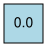

In [30]:
dot_string = mgr.to_dot(V_primed, title="Value Function")
display(graphviz.Source(dot_string))

In [33]:
# ── run ────────────────────────────────────────────────────────────────────────
DISCOUNT  = 0.95
TOLERANCE = 0.01

V, policy_adds = spudd(
    mgr,
    reward_adds,
    transition_adds,
    discount=DISCOUNT,
    tolerance=TOLERANCE
)

Iteration 1: delta = 460.000000, nodes = 22
Iteration 2: delta = 161.025661, nodes = 156
Iteration 3: delta = 152.974378, nodes = 171
Iteration 4: delta = 144.475125, nodes = 171
Iteration 5: delta = 137.251369, nodes = 171
Iteration 6: delta = 130.388775, nodes = 181
Iteration 7: delta = 123.869336, nodes = 177


Iteration 8: delta = 117.675869, nodes = 171
Iteration 9: delta = 111.792076, nodes = 181
Iteration 10: delta = 106.202472, nodes = 171
Iteration 11: delta = 100.892349, nodes = 171
Iteration 12: delta = 95.847731, nodes = 171
Iteration 13: delta = 91.055345, nodes = 171
Iteration 14: delta = 86.502577, nodes = 171
Iteration 15: delta = 82.177449, nodes = 171


Iteration 16: delta = 78.068576, nodes = 171
Iteration 17: delta = 74.165147, nodes = 171
Iteration 18: delta = 70.456890, nodes = 171
Iteration 19: delta = 66.934045, nodes = 171
Iteration 20: delta = 63.587343, nodes = 171
Iteration 21: delta = 60.407976, nodes = 171


Iteration 22: delta = 57.387577, nodes = 184
Iteration 23: delta = 54.518198, nodes = 179
Iteration 24: delta = 51.792288, nodes = 189
Iteration 25: delta = 49.202674, nodes = 179
Iteration 26: delta = 46.742540, nodes = 171
Iteration 27: delta = 44.405413, nodes = 171
Iteration 28: delta = 42.185143, nodes = 181
Iteration 29: delta = 40.075885, nodes = 171


Iteration 30: delta = 38.072091, nodes = 171
Iteration 31: delta = 36.168487, nodes = 181
Iteration 32: delta = 34.360062, nodes = 171
Iteration 33: delta = 32.642059, nodes = 179
Iteration 34: delta = 31.009956, nodes = 181
Iteration 35: delta = 29.459458, nodes = 181


...

Iteration 156: delta = 0.059399, nodes = 181
Iteration 157: delta = 0.056429, nodes = 181
Iteration 158: delta = 0.053608, nodes = 181
Iteration 159: delta = 0.050927, nodes = 171
Iteration 160: delta = 0.048381, nodes = 171
Iteration 161: delta = 0.045962, nodes = 181
Iteration 162: delta = 0.043664, nodes = 184
Iteration 163: delta = 0.041481, nodes = 181


Iteration 164: delta = 0.039407, nodes = 181
Iteration 165: delta = 0.037436, nodes = 179
Iteration 166: delta = 0.035565, nodes = 179
Iteration 167: delta = 0.033786, nodes = 179
Iteration 168: delta = 0.032097, nodes = 179
Iteration 169: delta = 0.030492, nodes = 181
Iteration 170: delta = 0.028968, nodes = 189
Iteration 171: delta = 0.027519, nodes = 181


Iteration 172: delta = 0.026143, nodes = 171
Iteration 173: delta = 0.024836, nodes = 181
Iteration 174: delta = 0.023594, nodes = 179
Iteration 175: delta = 0.022415, nodes = 176
Iteration 176: delta = 0.021294, nodes = 181
Iteration 177: delta = 0.020229, nodes = 181
Iteration 178: delta = 0.019218, nodes = 171
Iteration 179: delta = 0.018257, nodes = 189


Iteration 180: delta = 0.017344, nodes = 171
Iteration 181: delta = 0.016477, nodes = 189
Iteration 182: delta = 0.015653, nodes = 176
Iteration 183: delta = 0.014870, nodes = 181
Iteration 184: delta = 0.014127, nodes = 179
Iteration 185: delta = 0.013420, nodes = 171
Iteration 186: delta = 0.012749, nodes = 171
Iteration 187: delta = 0.012112, nodes = 181


Iteration 188: delta = 0.011506, nodes = 171
Iteration 189: delta = 0.010931, nodes = 176
Iteration 190: delta = 0.010384, nodes = 171
Iteration 191: delta = 0.009865, nodes = 181
Converged after 191 iterations.


In [34]:
# ── extract optimal action for a given state ───────────────────────────────────
def get_optimal_action(mgr, policy_adds, state):
    """
    state: dict e.g. {"X": 50, "Y": 100, "Z": 0}
    Returns index of optimal action.
    """
    
    # get action names
    action_names = list(reward_adds.keys())

    # evaluate each Q-value ADD at a given state
    q_vals = [mgr.evaluate(Q, state) for Q in policy_adds]

    # get index of the highest Q-value
    best   = int(np.argmax(q_vals))
    
    print(f"State {state}: Q-values = {dict(zip(action_names, q_vals))}, "
          f"optimal action = {action_names[best]}")
    return best

In [35]:
# example query
get_optimal_action(mgr, policy_adds, {"X": 50, "Y": 100, "Z": 0})

State {'X': 50, 'Y': 100, 'Z': 0}: Q-values = {'a1': np.float64(3315.1412832204005), 'a2': np.float64(3362.423799582008), 'a3': np.float64(3305.1412832204005)}, optimal action = a2


1

In [37]:
# visualize V (optimal value function)
import pandas as pd
import itertools

rows = []
for x, y, z in itertools.product(STATE_VALS, repeat=3):
    state = {"X": x, "Y": y, "Z": z}
    val = mgr.evaluate(V, state)
    rows.append({"X": x, "Y": y, "Z": z, "V": val})

df = pd.DataFrame(rows)
print(df)

      X    Y    Z            V
0     0    0    0  3212.414428
1     0    0   50  3262.414428
2     0    0  100  3302.414428
3     0    0  150  3352.414428
4     0   50    0  3262.414428
..  ...  ...  ...          ...
59  150  100  150  3515.283687
60  150  150    0  3462.154297
61  150  150   50  3512.154297
62  150  150  100  3515.220934
63  150  150  150  3562.292888

[64 rows x 4 columns]


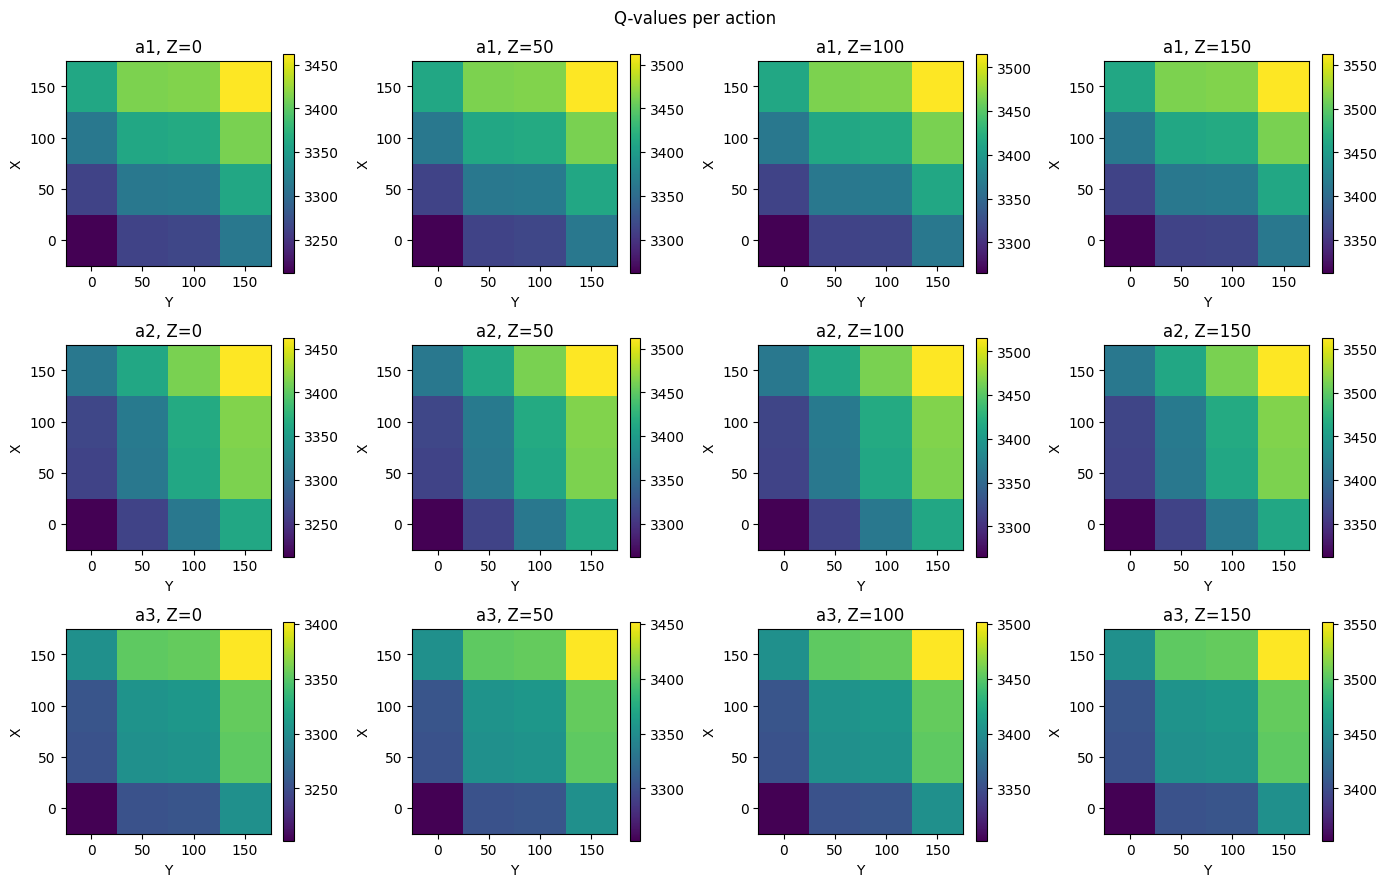

In [40]:
import matplotlib.pyplot as plt

action_names = list(reward_adds.keys())

fig, axes = plt.subplots(len(action_names), len(STATE_VALS), 
                         figsize=(14, 3 * len(action_names)))

for a_idx, a_name in enumerate(action_names):
    Q = policy_adds[a_idx]
    for col, z in enumerate(STATE_VALS):
        ax = axes[a_idx, col]
        grid = np.array([[mgr.evaluate(Q, {"X": x, "Y": y, "Z": z})
                          for y in STATE_VALS]
                         for x in STATE_VALS])
        im = ax.imshow(grid, origin="lower")
        ax.set_title(f"{a_name}, Z={z}")
        ax.set_xticks(range(len(STATE_VALS)))
        ax.set_xticklabels(STATE_VALS)
        ax.set_yticks(range(len(STATE_VALS)))
        ax.set_yticklabels(STATE_VALS)
        ax.set_xlabel("Y")
        ax.set_ylabel("X")
        plt.colorbar(im, ax=ax)

plt.suptitle("Q-values per action")
plt.tight_layout()
plt.show()

## trying with the original SPUDD code

In [65]:
import subprocess
import os
import time
import threading

In [24]:
os.getcwd()

'/home/jovyan/adaptive_coypu/factored_MDP'

In [25]:
RDDLSIM_DIR = "rddlsimSPUDD"

In [66]:
def print_server_output(server):
    while True:
        line = server.stdout.readline()
        if not line:
            break
        print("SERVER:", line.decode().strip())

In [29]:
def run_rddl(args, cwd=RDDLSIM_DIR):
    result = subprocess.run(
        ["bash", "run"] + args,
        cwd=cwd,
        capture_output=True,
        text=True
    )
    print(result.stdout)
    if result.stderr:
        print("STDERR:", result.stderr)
    return result

In [35]:
# convert rddl problem file into SPUDD format

run_rddl([
    "rddl.translate.RDDL2Format", # part of RDDLSim code, Java class that does translation -- don't change
    "files/boolean/rddl", # input directory containing .rddl problem files
    "files/boolean/spudd_sperseus", # output directory where the translated spudd files will be written
    "spudd_sperseus" # format to translate to
])

In [71]:
# kill anything already using port 2323
subprocess.run(["fuser", "-k", "2323/tcp"], capture_output=True)

time.sleep(1)

In [4]:
# command line version:

# start server
# bash run rddl.competition.Server files/boolean/rddl/

# run
# bash run rddl.competition.Client files/boolean/rddl localhost MyClientName rddl.policy.SPerseusSPUDDPolicy 2323 123456 elm4

In [72]:
# 1. start server (in background)
server = subprocess.Popen(
    ["bash", "run", "rddl.competition.Server", "files/boolean/rddl/"],
    # equivalent to typing `bash run rddl.competition.Server files/boolean/spudd_sperseus/` in the terminal
    cwd=RDDLSIM_DIR,
    stdout=subprocess.PIPE, # captures server's printed output so Python can read it rather than printing directly to the terminal
    stderr=subprocess.PIPE # captures server's error messages so Python can read it rather than printing directly to the terminal
)

In [73]:
# time.sleep(5)

# check what the server is saying
print("SERVER STDOUT:", server.stdout.read1(1024).decode())
print("SERVER STDERR:", server.stderr.read1(1024).decode())

SERVER STDOUT: Loading: files/boolean/rddl/elevator_bool_mdp.rddl
Loading: files/boolean/rddl/sysadmin_bool_mdp.rddl
Loading: files/boolean/rddl/sysadmin_bool_pomdp.rddl
Loading: files/boolean/rddl/elevator_bool_pomdp.rddl
Loading: files/boolean/rddl/traffic_bool_mdp.rddl
Loading: files/boolean/rddl/traffic_bool_pomdp.rddl
Loading: files/boolean/rddl/game_of_life_nointerm_pomdp.rddl
Loading: files/boolean/rddl/game_of_life_nointerm_mdp.rddl
RDDL Server Initialized



KeyboardInterrupt: 

In [ ]:
thread = threading.Thread(target=print_server_output, args=(server,))
thread.daemon = True
thread.start()

In [ ]:
# 2. run client
run_rddl([
    "rddl.competition.Client", # java class to run
    "files/boolean/rddl", # directory containing the rddl problem files
    "localhost", # address of server to connec to
    "MyClientName", # just a name to identify this client, can be anything
    "rddl.policy.SPerseusSPUDDPolicy", # policy class to use for decision making; SPUDD policy that reads the .spudd files
    "2323", # port number to connect to the server on; must match what the server is listening on
    "123456", # random seed
    "elm4" # problem instance to solve
])

In [70]:
# 3. kill server when done
server.terminate()